In [1]:
# Downloading a compressed version of the CSV data file from Open Food Facts.
!wget -q https://static.openfoodfacts.org/data/en.openfoodfacts.org.products.csv.gz -O food.csv.gz

In [2]:
# Importing the required libraries.
import pandas as pd
import matplotlib.pyplot as plt

# Storing only the relevant columns needed for the analysis based on the column names provided in the metadata on the Open Food Facts website.
columns_needed = [
    'code',
    'product_name',
    'categories_tags',
    'categories_en',
    'ingredients_text',
    'sugars_100g',
    'proteins_100g',
    'fat_100g',
    'fiber_100g',
    'carbohydrates_100g',
    'energy-kcal_100g',
    'nutriscore_grade',
]

df = pd.read_csv(
    "food.csv.gz",
    sep="\t",    # The character that separates fields is <tab> (tabulation) according to the metadata provided by the Open Food Facts database.
    compression="gzip",
    nrows=500_000,
    usecols=columns_needed,   # Only pulls the needed libraries
    low_memory=False,
    on_bad_lines="skip"
)

display(df.head())
print("The rows and columns in the dataset is:", {df.shape})

,code,product_name,categories_tags,categories_en,ingredients_text,nutriscore_grade,energy-kcal_100g,fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g
0,54,Limonade artisanale a la rose,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN
1,63,M&amp;M white,NaN,NaN,"Weizenmehl, Rapsöl, Speisesalz, 1,7% Meersalz,...",unknown,NaN,NaN,NaN,NaN,NaN,NaN
2,114,Chocolate n3,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN
3,431,Pâte de fruits,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN
4,105,Paleta gran reserva - Sierra nevada-,"en:beverages-and-beverages-preparations,en:bev...","Beverages and beverages preparations,Beverages","Thiamin, Biotin, Chromium, Garcinia cambogia f...",unknown,NaN,NaN,NaN,NaN,NaN,NaN


The rows and columns in the dataset is: {(500000, 12)}


## Story 1: Data Ingestion & "The Clean Up"

### Investigating The Missing Values In the Columns

,column,missing_count,missing_values_percentage
10,fiber_100g,416780,83.36
9,sugars_100g,388365,77.67
8,carbohydrates_100g,384967,76.99
7,fat_100g,384924,76.98
11,proteins_100g,384775,76.96
6,energy-kcal_100g,383898,76.78
4,ingredients_text,233042,46.61
3,categories_en,231922,46.38
2,categories_tags,231922,46.38
1,product_name,15789,3.16


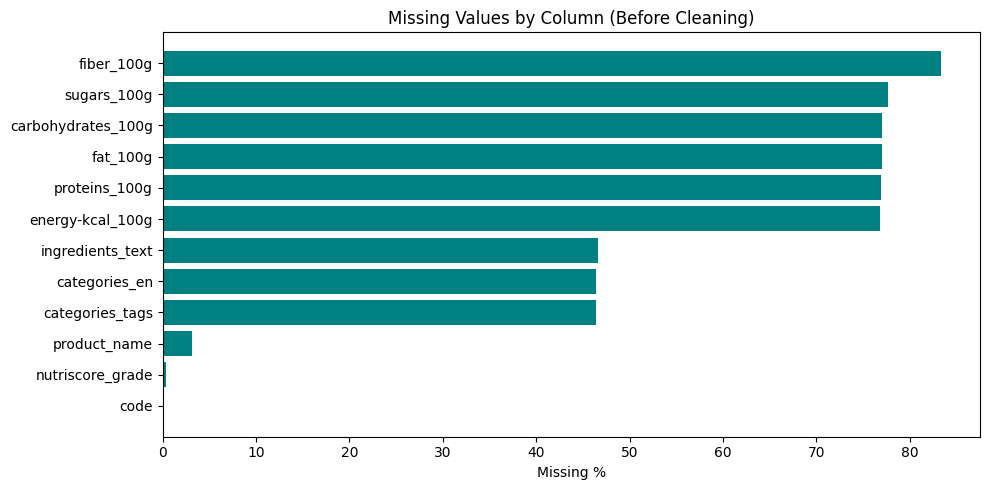

In [3]:
missing_values_summary = df.isnull().sum().reset_index()
missing_values_summary.columns = ['column', 'missing_count']
missing_values_summary['missing_values_percentage'] = (missing_values_summary['missing_count'] / len(df) * 100).round(2)
missing_values_summary = missing_values_summary.sort_values('missing_values_percentage', ascending=False)

display(missing_values_summary)

# Bar chart to display the missing values
plt.figure(figsize=(10, 5))
plt.barh(missing_values_summary['column'], missing_values_summary['missing_values_percentage'], color='teal')
plt.xlabel('Missing %')
plt.title('Missing Values by Column (Before Cleaning)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [4]:
# Checking for missing values in the core columns(columns relevant for the analysis)
core_columns = ['product_name', 'sugars_100g', 'proteins_100g', 'categories_tags']
df_clean = df.dropna(subset=core_columns).copy()

print(f"Before: {len(df):,} rows,  After dropping missing core fields: {len(df_clean):,} rows")
display(df_clean.head())

Before: 500,000 rows,  After dropping missing core fields: 52,857 rows


,code,product_name,categories_tags,categories_en,ingredients_text,nutriscore_grade,energy-kcal_100g,fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g
689,1000,Pinto Bean,en:asian-style-ready-meal,Asian-style-ready-meal,NaN,unknown,261.4,10.2,22.5,4.9,3.8,17.5
840,1001,pasta,"en:beverages-and-beverages-preparations,en:bev...","Beverages and beverages preparations,Beverages",NaN,c,166.0,6.4,20.0,1.9,0.8,6.7
865,100810429,Eirn original curry Sauce,"en:plant-based-foods-and-beverages,en:plant-ba...","Plant-based foods and beverages,Plant-based fo...",Wheat Flour Sugar Vegetable Fat D Curry Powder...,not-applicable,411.0,18.0,57.2,29.6,1.2,5.2
875,101019680,Donut Milka,"en:snacks,en:sweet-snacks,en:biscuits-and-cake...","Snacks,Sweet snacks,Biscuits and cakes,Cakes,D...",NaN,e,465.0,28.0,46.5,18.0,NaN,6.0
890,101209159,Véritable pâte à tartiner noisettes chocolat noir,"en:breakfasts,en:spreads,en:sweet-spreads,fr:p...","Breakfasts,Spreads,Sweet spreads,fr:Pâtes à ta...",NaN,e,617.0,48.0,36.0,32.0,NaN,8.0


In [5]:
nutrient_cols = ['sugars_100g', 'proteins_100g', 'fat_100g', 'fiber_100g', 'carbohydrates_100g']

# Summary statistics  for each nutrient column
print("Summary statistics for nutrient columns:")
display(df_clean[nutrient_cols].describe().T)

# Preview rows that still have at least one missing value among the nutrient columns
print("\n Sample rows with missing nutrient values:")
display(df_clean.loc[df_clean[nutrient_cols].isnull().any(axis=1)][nutrient_cols].head())

# Count of missing values per nutrient column
print("\n Missing value counts per nutrient column:")
display(df_clean[nutrient_cols].isnull().sum())

Summary statistics for nutrient columns:


,count,mean,std,min,25%,50%,75%,max
sugars_100g,52857.0,13.399956,175.714334,0.0,1.176471,4.800000,14.060000,40000.0
proteins_100g,52857.0,8.608032,39.297114,0.0,2.200000,6.600000,10.398509,6400.0
fat_100g,52788.0,11.522648,30.232196,0.0,0.519758,3.800000,15.300000,2520.0
fiber_100g,43356.0,3.053406,7.481829,0.0,0.000000,1.714286,3.797468,800.0
carbohydrates_100g,52552.0,35.316082,179.477635,0.0,7.893525,25.000000,57.000000,40000.0



 Sample rows with missing nutrient values:


,sugars_100g,proteins_100g,fat_100g,fiber_100g,carbohydrates_100g
875,18.0,6.000000,28.000000,NaN,46.5
890,32.0,8.000000,48.000000,NaN,36.0
946,0.0,0.000000,36.700001,NaN,0.0
947,4.1,22.299999,35.299999,NaN,5.1
954,0.2,40.500000,22.700000,NaN,2.4



 Missing value counts per nutrient column:


,0
sugars_100g,0
proteins_100g,0
fat_100g,69
fiber_100g,9501
carbohydrates_100g,305


In [6]:
# Outliers for each nutrient column
for col in nutrient_cols:
    outliers = df_clean[(df_clean[col] > 100) | (df_clean[col] < 0)][['product_name', col]] \
        .sort_values(col, ascending=False)
    print(f"\n{col}: {len(outliers)} outlier rows")
    display(outliers.head(5))


sugars_100g: 70 outlier rows


,product_name,sugars_100g
154062,solgar,40000.0
273906,Lemon-Lime Soda,2400.0
187909,Starburst Original,1600.0
390198,Cottage Cheese Small Curd,1600.0
46085,Snack Medleys,900.0



proteins_100g: 48 outlier rows


,product_name,proteins_100g
390198,Cottage Cheese Small Curd,6400.0
263127,Chicken korma and pilau rice,3190.0
64317,Chicken & Spinach Garlic Alfredo Bowl,3100.0
292026,PLANT-BASED PROTEIN SHAKE,2500.0
340518,Pea Soup with Smoked Ham,900.0



fat_100g: 111 outlier rows


,product_name,fat_100g
263127,Chicken korma and pilau rice,2520.0
2798,Tester,2321.0
86538,Ghee Clarified Butter,2000.0
286208,CLARIFIED BUTTER (ghee),2000.0
390198,Cottage Cheese Small Curd,1600.0



fiber_100g: 7 outlier rows


,product_name,fiber_100g
340518,Pea Soup with Smoked Ham,800.000000
418625,Mission zero carb tortillas,700.000000
215677,Baking Cocoa,400.000000
307426,ASHWAGANDHA+ GUMMIES,300.000000
110435,Premium Popcorn Movie Theater Butter,133.333333



carbohydrates_100g: 206 outlier rows


,product_name,carbohydrates_100g
154062,solgar,40000.0
340518,Pea Soup with Smoked Ham,2700.0
187909,Starburst Original,2400.0
273906,Lemon-Lime Soda,2400.0
2798,Tester,2312.0


In [7]:
row_len_before = len(df_clean)

for col in nutrient_cols:
    df_clean = df_clean[df_clean[col].isnull() | ((df_clean[col] >= 0) & (df_clean[col] <= 100))]

print(f"Row length before removing outliers: {row_len_before:,} After outlier removal: {len(df_clean):,}  (removed {row_len_before - len(df_clean):,})")
display(df_clean.head())

Row length before removing outliers: 52,857 After outlier removal: 52,565  (removed 292)


,code,product_name,categories_tags,categories_en,ingredients_text,nutriscore_grade,energy-kcal_100g,fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g
689,1000,Pinto Bean,en:asian-style-ready-meal,Asian-style-ready-meal,NaN,unknown,261.4,10.2,22.5,4.9,3.8,17.5
840,1001,pasta,"en:beverages-and-beverages-preparations,en:bev...","Beverages and beverages preparations,Beverages",NaN,c,166.0,6.4,20.0,1.9,0.8,6.7
865,100810429,Eirn original curry Sauce,"en:plant-based-foods-and-beverages,en:plant-ba...","Plant-based foods and beverages,Plant-based fo...",Wheat Flour Sugar Vegetable Fat D Curry Powder...,not-applicable,411.0,18.0,57.2,29.6,1.2,5.2
875,101019680,Donut Milka,"en:snacks,en:sweet-snacks,en:biscuits-and-cake...","Snacks,Sweet snacks,Biscuits and cakes,Cakes,D...",NaN,e,465.0,28.0,46.5,18.0,NaN,6.0
890,101209159,Véritable pâte à tartiner noisettes chocolat noir,"en:breakfasts,en:spreads,en:sweet-spreads,fr:p...","Breakfasts,Spreads,Sweet spreads,fr:Pâtes à ta...",NaN,e,617.0,48.0,36.0,32.0,NaN,8.0


In [8]:
# Track row count before the filtering step is performed, to report how many rows were removed
before = len(df_clean)

# Keep rows where carbohydrates is missing or,
# where sugar is not greater than carbohydrates ,
# since sugar is a subset of carbohydrates and should never exceed it biologically
df_clean = df_clean[
    df_clean['carbohydrates_100g'].isnull() |
    (df_clean['sugars_100g'] <= df_clean['carbohydrates_100g'] + 1)
]

# Reports how many rows were dropped for having sugar values impossibly higher than carbs
print(f"Removed {before - len(df_clean):,} rows where sugar > carbohydrates")

Removed 120 rows where sugar > carbohydrates


### Story 2: Category Wrangler

In [9]:
# See the most common category tags to be used for the keyword rules
from collections import Counter

all_tags = df_clean['categories_tags'].str.split(',').explode()
tag_counts = Counter(all_tags)

top_tags = pd.DataFrame(tag_counts.most_common(40), columns=['tag', 'count'])
display(top_tags)

,tag,count
0,en:plant-based-foods-and-beverages,21686
1,en:plant-based-foods,20114
2,en:cereals-and-potatoes,12482
3,en:snacks,9036
4,en:breads,7143
5,en:dairies,6766
6,en:sweet-snacks,6018
7,en:fermented-foods,5947
8,en:fermented-milk-products,5893
9,en:desserts,5361


,count
primary_category,
Beverages,14599
Bread & Bakery,7323
Dairy,6822
Other,5811
Chocolate & Candy,3490
Meat & Seafood,3255
Spreads & Condiments,3043
Cookies & Biscuits,3015
Chips & Savory Snacks,1784


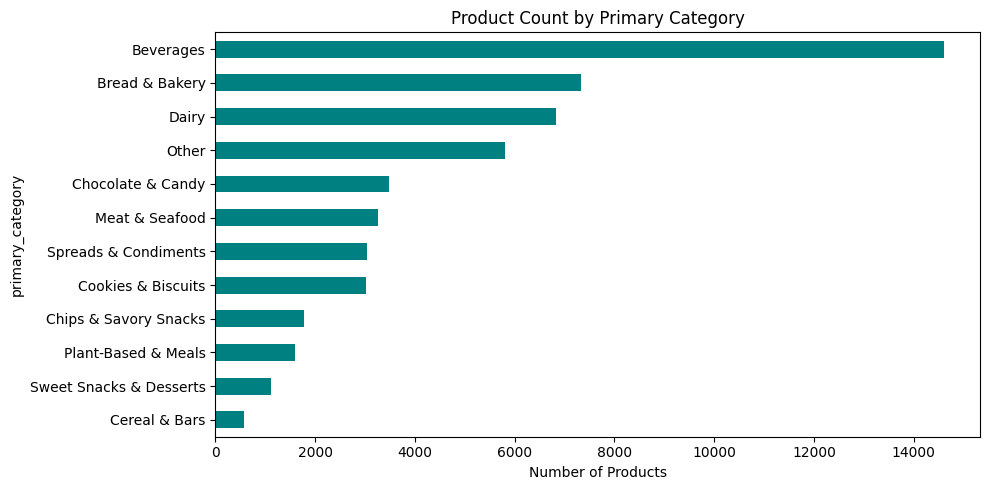

In [10]:
# Define keyword rules for each high-level bucket
# In this case, order matters. First match wins, so specific categories come before generic ones

def assign_primary_category(tags_string):
    if pd.isnull(tags_string):
        return 'Other'

    tags = tags_string.lower()

    category_rules = [
        ('Chocolate & Candy', ['chocolate', 'candies', 'candy', 'confectioner', 'cocoa']),
        ('Cookies & Biscuits', ['biscuit', 'cake', 'pastry', 'pastries']),
        ('Chips & Savory Snacks', ['chips-and-fries', 'crisps', 'salty-snacks', 'popcorn', 'pretzel']),
        ('Bread & Bakery', ['bread']),
        ('Dairy', ['dairy', 'cheese', 'yogurt', 'yoghurt', 'fermented-milk']),
        ('Beverages', ['beverage', 'drink', 'soda', 'juice']),
        ('Meat & Seafood', ['meat', 'seafood', 'fish', 'poultry']),
        ('Cereal & Bars', ['cereal', 'granola', 'muesli', 'breakfast']),
        ('Spreads & Condiments', ['spread', 'sauce', 'condiment', 'jam']),
        ('Sweet Snacks & Desserts', ['sweet-snacks', 'dessert', 'confection']),
        ('Plant-Based & Meals', ['plant-based', 'meal', 'ready-meal', 'legume']),
    ]

    for category_name, keywords in category_rules:
        if any(kw in tags for kw in keywords):
            return category_name

    return 'Other'

df_clean['primary_category'] = df_clean['categories_tags'].apply(assign_primary_category)

category_counts = df_clean['primary_category'].value_counts()
display(category_counts)

plt.figure(figsize=(10, 5))
category_counts.plot(kind='barh', color='teal')
plt.xlabel('Number of Products')
plt.title('Product Count by Primary Category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Story 3: The "Nutrient Matrix" Visualization

In [11]:
# Scatter chart itself is will be built in Power BI, this is just to prepare the underlying data used to build the scatter chart.

# "Empty Quadrant" = high protein (that is greater than 10g/100g), low sugar ( less than 5g/100g)
empty_quadrant = df_clean[(df_clean['sugars_100g'] < 5) & (df_clean['proteins_100g'] > 10)].copy()

print(f"Empty Quadrant products: {len(empty_quadrant):,} of {len(df_clean):,} "
      f"({len(empty_quadrant)/len(df_clean)*100:.1f}%)")
display(empty_quadrant['primary_category'].value_counts())

# For each category: total products vs. how many ,lands in the Empty Quadrant
total_by_cat = df_clean.groupby('primary_category').size().rename('total_products')
quadrant_by_cat = empty_quadrant.groupby('primary_category').size().rename('in_quadrant')

gap_analysis = pd.concat([total_by_cat, quadrant_by_cat], axis=1).fillna(0)
gap_analysis['in_quadrant'] = gap_analysis['in_quadrant'].astype(int)
gap_analysis['pct_in_quadrant'] = (gap_analysis['in_quadrant'] / gap_analysis['total_products'] * 100).round(2)
gap_analysis = gap_analysis.sort_values('pct_in_quadrant')

display(gap_analysis)

Empty Quadrant products: 9,436 of 52,445 (18.0%)


,count
primary_category,
Meat & Seafood,2424
Beverages,2004
Dairy,1591
Other,1363
Bread & Bakery,1325
Plant-Based & Meals,269
Cookies & Biscuits,193
Chips & Savory Snacks,108
Spreads & Condiments,87


,total_products,in_quadrant,pct_in_quadrant
primary_category,,,
Sweet Snacks & Desserts,1116,11,0.99
Chocolate & Candy,3490,50,1.43
Cereal & Bars,580,11,1.90
Spreads & Condiments,3043,87,2.86
Chips & Savory Snacks,1784,108,6.05
Cookies & Biscuits,3015,193,6.40
Beverages,14599,2004,13.73
Plant-Based & Meals,1607,269,16.74
Bread & Bakery,7323,1325,18.09


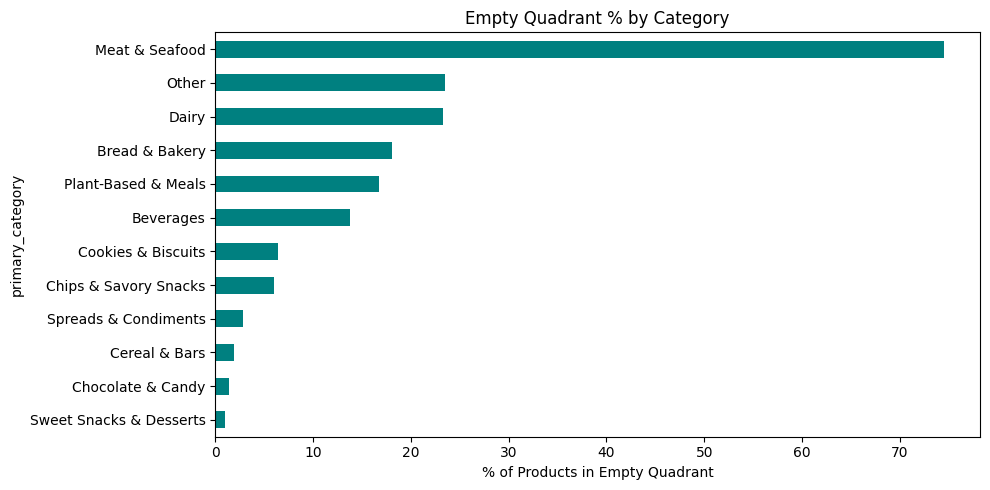

In [17]:
# Bar chart: Empty Quadrant % by category, sorted from lowest to highest
plt.figure(figsize=(10, 5))
gap_analysis['pct_in_quadrant'].plot(kind='barh', color='teal')
plt.xlabel('% of Products in Empty Quadrant')
plt.title('Empty Quadrant % by Category')
plt.tight_layout()
plt.show()

### Story 4: The Recommendation

In [16]:
# Find the category with the biggest gap between total size and Empty Quadrant presence
top_opportunity = gap_analysis[gap_analysis['total_products'] > 500].sort_values('pct_in_quadrant').head(1)
display(top_opportunity)

# Suggested target numbers: median protein/sugar of the existing good products are used as a realistic benchmark
target_protein = empty_quadrant['proteins_100g'].median()
target_sugar = empty_quadrant['sugars_100g'].median()

print(f"Top opportunity category: {top_opportunity.index[0]}")
print(f"Suggested targets: {target_protein:.1f}g protein, less than {target_sugar:.1f}g sugar")

,total_products,in_quadrant,pct_in_quadrant
primary_category,,,
Sweet Snacks & Desserts,1116,11,0.99


Top opportunity category: Sweet Snacks & Desserts
Suggested targets: 16.1g protein, less than 0.9g sugar


###  Bonus User Story: The "Hidden Gem"

In [18]:
# Scoped to the recommended opportunity category, this will be the evidence that supports the recommendation.

target_category = top_opportunity.index[0]

good_products = empty_quadrant[
    (empty_quadrant['primary_category'] == target_category) &
    (empty_quadrant['ingredients_text'].notnull())
]

print(f"'{target_category}' products in the Empty Quadrant with ingredient text: {len(good_products)}")

protein_sources = ['whey', 'soy', 'pea protein', 'peanut', 'almond', 'egg', 'casein',
                    'milk protein', 'chicken', 'lentil', 'chickpea', 'oat', 'quinoa']

source_counts = {}
ingredients_lower = good_products['ingredients_text'].str.lower()

for source in protein_sources:
    count = ingredients_lower.str.contains(source, na=False).sum()
    source_counts[source] = count

source_df = pd.DataFrame(list(source_counts.items()), columns=['protein_source', 'count']) \
    .sort_values('count', ascending=False)

display(source_df.head(10))
print(f"\nTop 3 protein sources: {list(source_df.head(3)['protein_source'])}")

'Sweet Snacks & Desserts' products in the Empty Quadrant with ingredient text: 8


,protein_source,count
1,soy,6
0,whey,3
3,peanut,3
4,almond,2
7,milk protein,2
6,casein,1
5,egg,1
2,pea protein,0
8,chicken,0
9,lentil,0



Top 3 protein sources: ['soy', 'whey', 'peanut']


In [19]:
display(good_products[['product_name', 'ingredients_text', 'sugars_100g', 'proteins_100g']])

,product_name,ingredients_text,sugars_100g,proteins_100g
8685,Ice cream sticks Vanilla,"Eau, protéines de LAIT, blanc d'OEUF en poudre...",1.100000,12.000000
69175,Daifuku Yuzu,"Bohnenmus, weise Stangenbonnen, Zucker, Wasser...",0.000000,55.882353
73390,Protein One Protein Bars Peanut Butter Chocolate,"Soy Protein Isolate, Chicory Root Extract, Whe...",3.703704,37.037037
74200,Chocolate Nut Chewy Bar,"Almonds, Peanuts, Chicory Root Extract, Soy Pr...",2.500000,27.500000
74823,General mills calorie chocolate peanut butter ...,DE SOYA. CONTIENE GLUTEN.,4.347826,21.739130
75235,chocolate caramel and pretzel bars,"Extracto de raíz de aohicoria, harina de arroz...",4.347826,17.391304
351915,Protein Bar chocolate peanut butter,"Hydrolyzed gelatin, peanut flour, protein blen...",4.000000,40.000000
351959,Gâteau au citron,Mélange de protéines (isolat de protéines de l...,4.000000,40.000000


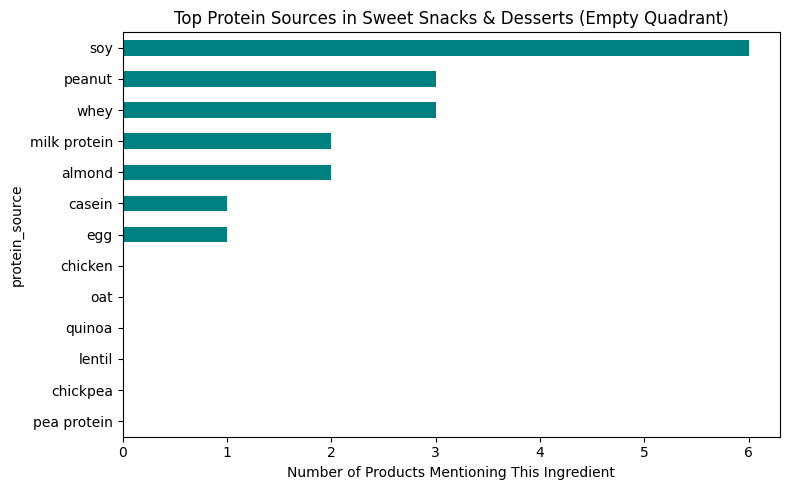

In [20]:
# Bar chart: top protein sources found in Hidden Gem products
plt.figure(figsize=(8, 5))
source_df.set_index('protein_source')['count'].sort_values().plot(kind='barh', color='teal')
plt.xlabel('Number of Products Mentioning This Ingredient')
plt.title(f'Top Protein Sources in {target_category} (Empty Quadrant)')
plt.tight_layout()
plt.show()

## 6. The "Candidate's Choice" Challenge

,count
nutriscore_grade,
d,393
e,279
c,279
unknown,75
not-applicable,36
b,30
a,24


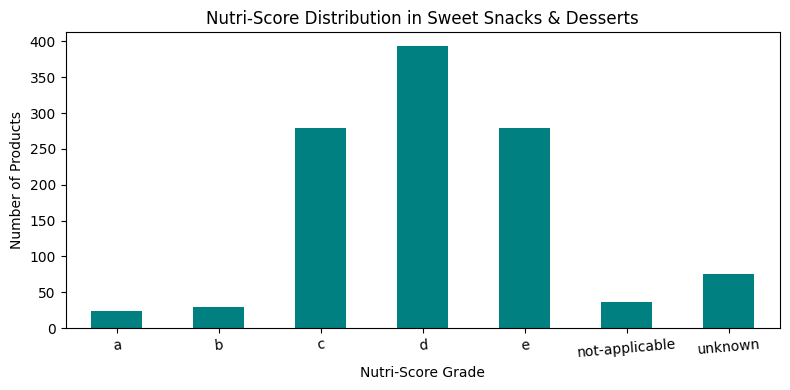

In [22]:
# For the recommended opportunity category, show current Nutri-Score distribution
# demonstrates that existing products in that space already score poorly
target_category = top_opportunity.index[0]

category_data = df_clean[df_clean['primary_category'] == target_category]
score_dist = category_data['nutriscore_grade'].value_counts()
display(score_dist)

plt.figure(figsize=(8, 4))
score_dist.sort_index().plot(kind='bar', color='teal')
plt.xlabel('Nutri-Score Grade')
plt.ylabel('Number of Products')
plt.title(f'Nutri-Score Distribution in {target_category}')
plt.xticks(rotation=5)
plt.tight_layout()
plt.show()

In [ ]:
#Exporting all the required files to be used for visualization in PowerBI.
# 1. Main dataset for every product and used for the scatter chart + slicer visualization in PowerBI
df_clean['is_empty_quadrant'] = (df_clean['sugars_100g'] < 5) & (df_clean['proteins_100g'] > 10)
df_clean.to_csv('cleaned_snack_data.csv', index=False)

# 2. Category-level gap summary, shows which category has the biggest gap in a bar chart
gap_analysis.to_csv('gap_analysis.csv')

# 3. Protein-source counts shows  the "Hidden Gem" ingredient chart
source_df.to_csv('protein_sources.csv', index=False)

from google.colab import files
files.download('cleaned_snack_data.csv')
files.download('gap_analysis.csv')
files.download('protein_sources.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>